# LJ Pair MD Notebook

Uses the neighbor-list path in `md.py` to run a pairwise Lennard-Jones test with:
1. a padded fixed-width neighbor list
2. periodic boundary conditions
3. a full-configuration pair potential differentiated with `jax.value_and_grad`

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from ase.build import bulk

from md import MD, Timer
from potentials import get_potential
from trajectory_viz import export_paraview_trajectory

## 1. Define The Pair Potential

Here the potential follows the full-configuration interface
`potential(positions, neighbor_list, box)`.
Internally it calls `pair_distances(...)` from `neighbor_list.py`.

In [2]:
sigma = 1.0
eps = 1.0
r_skin = 0.3 * sigma
temperature = 0.72
density = 0.844
a = (4/density)**(1/3)
fcc_lattice_constant = a
fcc_repetitions = (3, 3, 3)
max_neighbors = 64

potential = get_potential("lennard_jones", eps=eps, sigma=sigma)

## 2. Initial Conditions

In [3]:
dt = 0.004
m  = 1.0

key = jax.random.PRNGKey(42)
key_v = key

atoms = bulk('Cu', 'fcc', a=fcc_lattice_constant, cubic=True).repeat(fcc_repetitions)
r0 = jnp.array(atoms.get_positions(), dtype=jnp.float32)
box = jnp.array(atoms.cell.lengths(), dtype=jnp.float32)
N = len(atoms)
r_cut = min(2.5 * sigma, 0.45 * float(jnp.min(box)))
v0 = MD.initialize_velocities(N, temperature=temperature, m=m, rng_key=key_v)
a0 = jnp.zeros((N, 3))

print(f"fcc repetitions: {fcc_repetitions}")
print(f"box: {box}")
print(f"N: {N}")
print(f"temperature: {temperature}")
print(f"r_cut: {r_cut:.3f}, r_skin: {r_skin:.3f}, max_neighbors: {max_neighbors}")
print(f"r0: {r0.shape}, v0: {v0.shape}, a0: {a0.shape}")

fcc repetitions: (3, 3, 3)
box: [5.0391865 5.0391865 5.0391865]
N: 108
temperature: 0.72
r_cut: 2.268, r_skin: 0.300, max_neighbors: 64
r0: (108, 3), v0: (108, 3), a0: (108, 3)


## 3. Run — with progress bar (default)

In [4]:
sim = MD(
    r0,
    v0,
    a0,
    potential,
    dt=dt,
    m=m,
    neighbor_list_mode="many-body",
    box=box,
    r_cut=r_cut,
    r_skin=r_skin,
    neighbor_list_pbc=True,
    neighbor_list_padded=True,
    neighbor_list_max_neighbors=max_neighbors,
)

with Timer("MD run (progress mode)"):
    traj = sim.run(n_steps=400, chunk_size=20, progress_backend="notebook")

print(f"positions trajectory : {traj['positions'].shape}")
print(f"forces trajectory    : {traj['forces'].shape}")
print(f"temperature shape    : {traj['temperature'].shape}")
print(f"final positions      : {sim.r.shape}")

MD simulation:   0%|          | chunk 0/20  [00:00<?, ?chunk/s]

[MD run (progress mode)] elapsed: 4.4153s
positions trajectory : (400, 108, 3)
forces trajectory    : (400, 108, 3)
temperature shape    : (400,)
final positions      : (108, 3)


## 4. Save & reload trajectory

In [5]:
sim.save_trajectory('trajectory')

loaded = MD.load_trajectory('trajectory.npz')
print({k: v.shape for k, v in loaded.items()})

Trajectory saved to trajectory.npz
{'positions': (400, 108, 3), 'velocities': (400, 108, 3), 'accelerations': (400, 108, 3), 'forces': (400, 108, 3), 'potential_energy': (400,), 'kinetic_energy': (400,), 'temperature': (400,)}


## 5. Analysis

### Kinetic energy

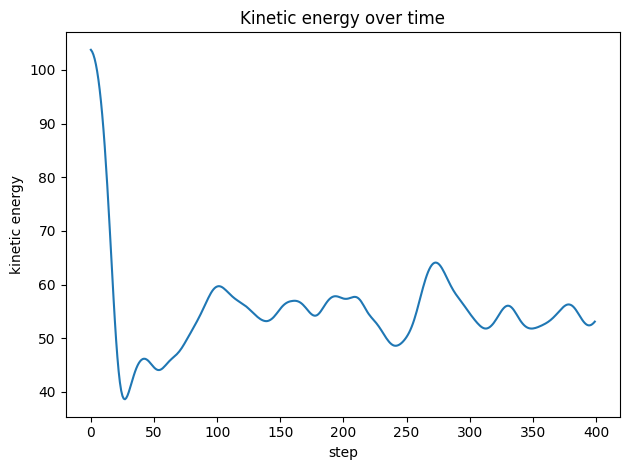

In [6]:
ke = traj['kinetic_energy']

plt.figure()
plt.plot(ke)
plt.xlabel('step')
plt.ylabel('kinetic energy')
plt.title('Kinetic energy over time')
plt.tight_layout()
plt.show()

### Mean squared displacement (MSD)

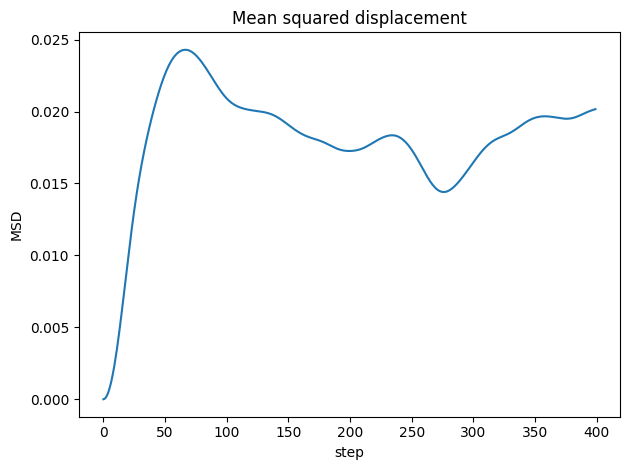

In [7]:
r_traj = traj['positions']                               # (n_steps, N, 3)
disp   = r_traj - r_traj[0]                             # displacement from t=0
msd    = np.mean(np.sum(disp ** 2, axis=-1), axis=-1)   # (n_steps,)

plt.figure()
plt.plot(msd)
plt.xlabel('step')
plt.ylabel('MSD')
plt.title('Mean squared displacement')
plt.tight_layout()
plt.show()

### Instantaneous Temperature

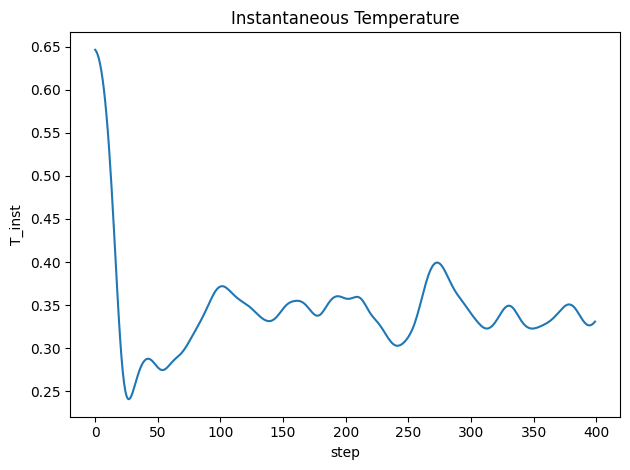

In [8]:
T_inst = traj['temperature']

plt.figure()
plt.plot(T_inst)
plt.xlabel('step')
plt.ylabel('T_inst')
plt.title('Instantaneous Temperature')
plt.tight_layout()
plt.show()

### Total Energy vs. Time-step

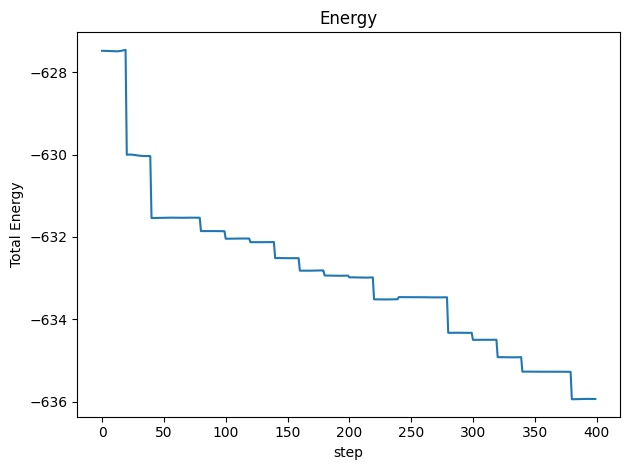

In [9]:
ke = traj['kinetic_energy']
pe = traj["potential_energy"]
te = ke + pe


plt.figure()
plt.plot(te)
plt.xlabel('step')
plt.ylabel('Total Energy')
plt.title('Energy')
plt.tight_layout()
plt.show()

## 6. ParaView Export

In [10]:
frame_stride = 5
export_result = export_paraview_trajectory(
    traj,
    output_dir='paraview_lj_pbc',
    box=np.array(box),
    every_nth=frame_stride,
    wrap=True,
)

print(f"Exported {export_result['n_exported_frames']} frames")
print(f"Open {export_result['pvd_path']} in ParaView")

Exported 80 frames
Open paraview_lj_pbc/trajectory.pvd in ParaView
